# 02 · Modelado del consumo combinado y las emisiones de CO₂

**Objetivo:** predecir el consumo combinado homologado (`Comb FE (Guide)`, mpg) y las emisiones de CO₂ (g/mi) de un
vehículo de combustión a partir de su especificación técnica (motor, transmisión, tracción, clase, combustible),
sin usar ninguna medida derivada del propio ensayo.

## Protocolo de evaluación

| Elemento | Decisión | Motivo |
|---|---|---|
| Hold-out | 30 % de las **familias de modelo** (`GroupShuffleSplit`) | Las variantes 2WD/AWD de un modelo no se reparten entre entrenamiento y prueba |
| CV aleatoria | `KFold(5)` | Comparable con la literatura y con evaluaciones previas |
| CV agrupada | `GroupKFold(5)` por familia | **Métrica de selección**: rendimiento sobre modelos de vehículo no vistos |
| Preprocesado | Dentro de `Pipeline` | Escalado y one-hot se ajustan sólo con datos de entrenamiento (sin fuga) |
| Referencia | `DummyRegressor` (media) | Todo modelo debe superar claramente a predecir la media |
| Métricas | MAE y RMSE en mpg, R² | Unidades interpretables por negocio |

In [1]:
try:
    import vehicle_emissions  # instalado con `pip install -e .`
except ModuleNotFoundError:  # ejecución directa sin instalar el paquete
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures

from vehicle_emissions.data import add_binary_features, load_fe_guide
from vehicle_emissions.evaluation import evaluate_regressor, plot_pred_vs_real, plot_residuals, results_table
from vehicle_emissions.validation import validate_fe_guide

df = add_binary_features(load_fe_guide())
validate_fe_guide(df)  # contrato de datos: detiene la ejecución si algo no cuadra
for c in ["Comb FE (Guide)", "Comb CO2"]:
    df[c] = df[c].astype(float)
print(f"{len(df)} vehículos · {df['Model Family'].nunique()} familias de modelo")

964 vehículos · 596 familias de modelo


## 1. Variables y partición

| Grupo | Variables |
|---|---|
| Numéricas | `Eng Displ`, `# Cyl`, `# Gears`, `Hybrid` |
| Codificación binaria compacta | `AWD/4WD`, `Large` |
| Categóricas (one-hot) | `Fuel Usage`, `Drive Desc`, `Carline Class Desc`, `Air Aspiration Method Desc`, `Cyl Deact?` |

In [3]:
TARGET = "Comb FE (Guide)"
NUM = ["Eng Displ", "# Cyl", "# Gears", "Hybrid"]
BIN = ["AWD/4WD", "Large"]
CAT = ["Fuel Usage", "Drive Desc", "Carline Class Desc", "Air Aspiration Method Desc", "Cyl Deact?"]
GROUPS = df["Model Family"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
idx_tr, idx_te = next(splitter.split(df, groups=GROUPS))
train, test = df.iloc[idx_tr], df.iloc[idx_te]
assert not set(train["Model Family"]) & set(test["Model Family"]), "fuga de familias entre train y test"
print(f"Entrenamiento: {len(train)} vehículos · Prueba: {len(test)} vehículos · familias compartidas: 0")

results = []
def run(name, model, cols, target=TARGET, data=df):
    tr, te = data.loc[data.index.isin(train.index)], data.loc[data.index.isin(test.index)]
    r = evaluate_regressor(name, model, tr[cols], te[cols], tr[target], te[target],
                           data[cols], data[target], groups=data["Model Family"])
    r.update(_y_test=te[target].to_numpy(), _model=model, _X_test=te[cols])
    results.append(r)
    return r

Entrenamiento: 668 vehículos · Prueba: 296 vehículos · familias compartidas: 0


## 2. Referencia

In [4]:
run("M0 Referencia · media", DummyRegressor(), NUM)
results_table(results)

,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
M0 Referencia · media,5.243,7.202,-0.001,-0.011,0.011,-0.001,4.95


## 3. Modelos lineales con codificación binaria

Se verifica explícitamente que normalizar no altera una regresión lineal (el modelo es invariante a
transformaciones afines de las variables), de modo que el escalado sólo se mantiene por estabilidad numérica.

In [5]:
cols_bin = NUM + BIN
r1 = run("M1 Lineal · binaria", LinearRegression(), cols_bin)
check = make_pipeline(MinMaxScaler(), LinearRegression()).fit(train[cols_bin], train[TARGET])
assert np.allclose(check.predict(test[cols_bin]), r1["_y_pred"]), "el escalado no debería cambiar la regresión lineal"
print("Invarianza al escalado verificada")

r2 = run("M2 Polinómica g2 · binaria",
         make_pipeline(MinMaxScaler(), PolynomialFeatures(degree=2), LinearRegression()), cols_bin)
results_table(results)

Invarianza al escalado verificada


,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
M0 Referencia · media,5.243,7.202,-0.001,-0.011,0.011,-0.001,4.950
M1 Lineal · binaria,2.817,3.800,0.721,0.726,0.022,0.722,2.604
M2 Polinómica g2 · binaria,2.418,3.270,0.794,0.794,0.011,0.781,2.289


## 4. Regresión lineal con one-hot encoding

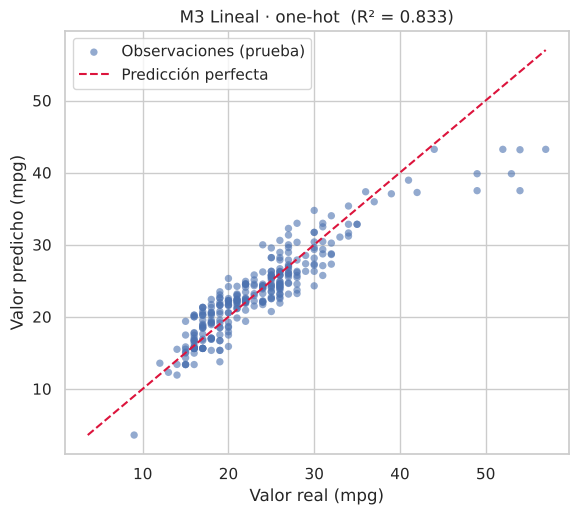

In [6]:
def preprocessor(scale=True):
    return ColumnTransformer([("num", MinMaxScaler() if scale else "passthrough", NUM),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

r3 = run("M3 Lineal · one-hot", Pipeline([("pre", preprocessor()), ("model", LinearRegression())]), NUM + CAT)
plot_pred_vs_real(r3["_y_test"], r3["_y_pred"], "M3 Lineal · one-hot", "(mpg)", save_as="02_M3_lineal_onehot.png")
plt.show()

## 5. Gradient Boosting con ajuste de hiperparámetros

La búsqueda se hace **sólo sobre el conjunto de entrenamiento** con `GroupKFold`, de modo que la partición de
prueba no interviene en ninguna decisión.

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
MAE en CV agrupada (entrenamiento): 1.50 mpg


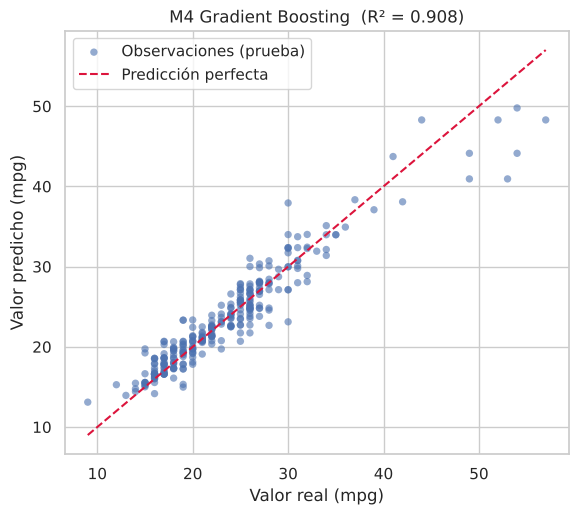

In [7]:
gb_pipe = Pipeline([("pre", preprocessor(scale=False)), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
search = GridSearchCV(
    gb_pipe,
    {"model__n_estimators": [200, 400], "model__max_depth": [2, 3, 4], "model__learning_rate": [0.05, 0.1],
     "model__subsample": [0.8, 1.0]},
    cv=GroupKFold(n_splits=5), scoring="neg_mean_absolute_error", n_jobs=-1,
)
search.fit(train[NUM + CAT], train[TARGET], groups=train["Model Family"])
print("Mejores hiperparámetros:", {k.split("__")[1]: v for k, v in search.best_params_.items()})
print(f"MAE en CV agrupada (entrenamiento): {-search.best_score_:.2f} mpg")

r4 = run("M4 Gradient Boosting · one-hot", search.best_estimator_, NUM + CAT)
plot_pred_vs_real(r4["_y_test"], r4["_y_pred"], "M4 Gradient Boosting", "(mpg)", save_as="02_M4_gradient_boosting.png")
plt.show()

## 6. Comparación de modelos

In [8]:
tabla = results_table(results)
tabla

,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
M0 Referencia · media,5.243,7.202,-0.001,-0.011,0.011,-0.001,4.950
M1 Lineal · binaria,2.817,3.800,0.721,0.726,0.022,0.722,2.604
M2 Polinómica g2 · binaria,2.418,3.270,0.794,0.794,0.011,0.781,2.289
M3 Lineal · one-hot,2.088,2.943,0.833,0.843,0.009,0.837,1.956
M4 Gradient Boosting · one-hot,1.485,2.181,0.908,0.921,0.007,0.906,1.412


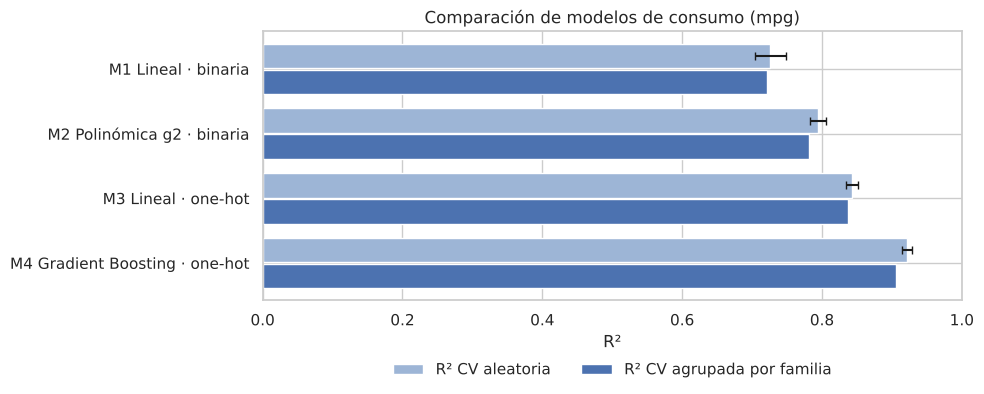

In [9]:
t = tabla.drop(index="M0 Referencia · media")
fig, ax = plt.subplots(figsize=(10, 4.2))
y = np.arange(len(t))
ax.barh(y - 0.2, t["R2 CV"], height=0.38, color="#9DB5D6", label="R² CV aleatoria")
ax.barh(y + 0.2, t["R2 CV agrupada"], height=0.38, color="#4C72B0", label="R² CV agrupada por familia")
ax.errorbar(t["R2 CV"], y - 0.2, xerr=t["± std"], fmt="none", color="k", capsize=3)
ax.set_yticks(y, t.index); ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("R²")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
ax.set_title("Comparación de modelos de consumo (mpg)")
fig.tight_layout(); fig.savefig("../reports/figures/02_comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Estudios de robustez

### 7.1 Ablación de variables

¿Cuánto aporta cada bloque? Se reentrena el mejor modelo retirando grupos de variables.

In [10]:
best_params = {k.split("__")[1]: v for k, v in search.best_params_.items()}
def gb_with(num, cat):
    pre = ColumnTransformer([("num", "passthrough", num)] + ([("cat", OneHotEncoder(handle_unknown="ignore"), cat)] if cat else []))
    return Pipeline([("pre", pre), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params))])

from sklearn.model_selection import cross_validate
abl = {}
for name, num, cat in [("Completo", NUM, CAT),
                       ("Sin `Hybrid`", [c for c in NUM if c != "Hybrid"], CAT),
                       ("Sin clase de vehículo", NUM, [c for c in CAT if c != "Carline Class Desc"]),
                       ("Sólo motor (cilindrada, cilindros, marchas, híbrido)", NUM, []),
                       ("Sólo cilindrada", ["Eng Displ"], [])]:
    s = cross_validate(gb_with(num, cat), df[num + cat], df[TARGET], groups=GROUPS, cv=GroupKFold(5),
                       scoring=("r2", "neg_mean_absolute_error"))
    abl[name] = {"R² CV agrupada": s["test_r2"].mean(), "MAE CV agrupada": -s["test_neg_mean_absolute_error"].mean()}
pd.DataFrame(abl).T.round(3)

,R² CV agrupada,MAE CV agrupada
Completo,0.906,1.412
Sin `Hybrid`,0.769,1.835
Sin clase de vehículo,0.885,1.558
"Sólo motor (cilindrada, cilindros, marchas, híbrido)",0.807,2.067
Sólo cilindrada,0.608,2.656


### 7.2 Sensibilidad a valores extremos

Los extremos de consumo son híbridos reales. Se comprueba si recortarlos (P98 del entrenamiento) mejora el modelo
lineal o sólo maquilla la métrica eliminando los casos difíciles.

In [11]:
q98 = train[TARGET].quantile(0.98)
trimmed = df[df[TARGET] < q98]
r_trim = evaluate_regressor("M3 sin extremos (P98)", Pipeline([("pre", preprocessor()), ("model", LinearRegression())]),
                            trimmed.loc[trimmed.index.isin(train.index), NUM + CAT], trimmed.loc[trimmed.index.isin(test.index), NUM + CAT],
                            trimmed.loc[trimmed.index.isin(train.index), TARGET], trimmed.loc[trimmed.index.isin(test.index), TARGET],
                            trimmed[NUM + CAT], trimmed[TARGET], groups=trimmed["Model Family"])
print(f"Umbral P98 = {q98:.0f} mpg · vehículos eliminados: {len(df) - len(trimmed)} "
      f"({(df[TARGET] >= q98).groupby(df['Hybrid']).sum().get(1, 0)} híbridos)")
results_table([r3, r_trim])

Umbral P98 = 40 mpg · vehículos eliminados: 24 (23 híbridos)


,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
M3 Lineal · one-hot,2.088,2.943,0.833,0.843,0.009,0.837,1.956
M3 sin extremos (P98),1.797,2.223,0.824,0.818,0.038,0.816,1.798


### 7.3 Elección del objetivo: mpg frente a CO₂

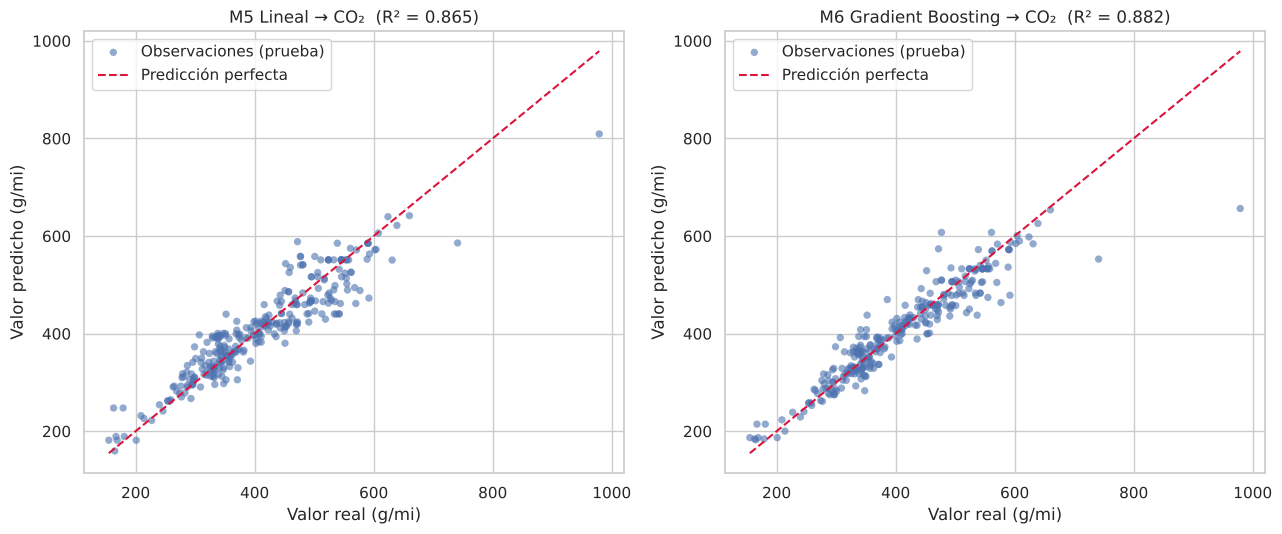

,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
M3 Lineal · one-hot,2.088,2.943,0.833,0.843,0.009,0.837,1.956
M5 Lineal · one-hot → CO₂ (g/mi),29.475,40.221,0.865,0.847,0.023,0.848,29.674
M4 Gradient Boosting · one-hot,1.485,2.181,0.908,0.921,0.007,0.906,1.412
M6 Gradient Boosting · one-hot → CO₂ (g/mi),23.592,37.514,0.882,0.892,0.026,0.887,23.232


In [12]:
r5 = run("M5 Lineal · one-hot → CO₂ (g/mi)", Pipeline([("pre", preprocessor()), ("model", LinearRegression())]),
         NUM + CAT, target="Comb CO2")
r6 = run("M6 Gradient Boosting · one-hot → CO₂ (g/mi)",
         Pipeline([("pre", preprocessor(scale=False)), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **best_params))]),
         NUM + CAT, target="Comb CO2")
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
plot_pred_vs_real(r5["_y_test"], r5["_y_pred"], "M5 Lineal → CO₂", "(g/mi)", ax=axs[0])
plot_pred_vs_real(r6["_y_test"], r6["_y_pred"], "M6 Gradient Boosting → CO₂", "(g/mi)", ax=axs[1])
fig.tight_layout(); fig.savefig("../reports/figures/02_M5-M6_co2.png", dpi=150, bbox_inches="tight")
plt.show()
results_table(results).loc[["M3 Lineal · one-hot", "M5 Lineal · one-hot → CO₂ (g/mi)",
                            "M4 Gradient Boosting · one-hot", "M6 Gradient Boosting · one-hot → CO₂ (g/mi)"]]

## 8. Diagnóstico del modelo seleccionado (M4)

### 8.1 Residuos

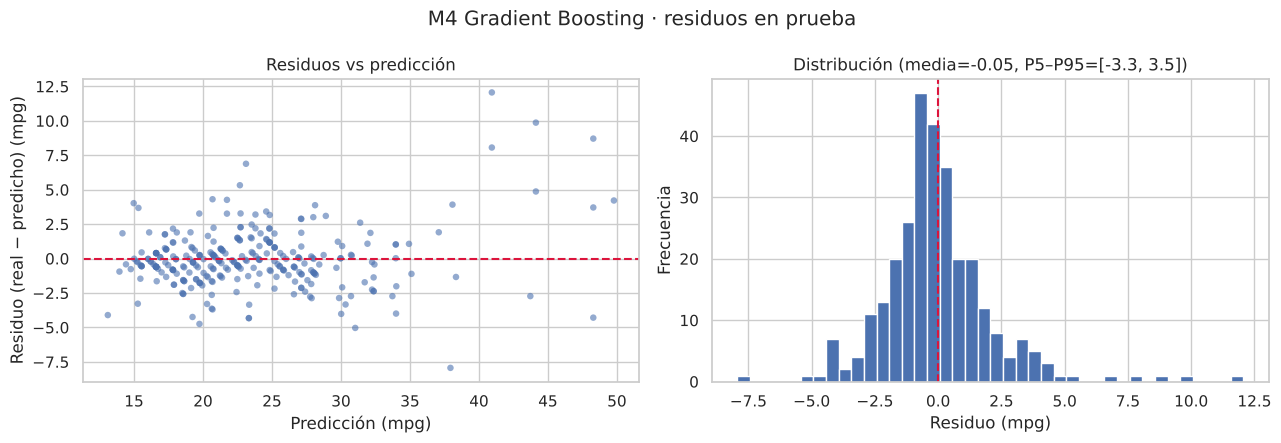

In [13]:
plot_residuals(r4["_y_test"], r4["_y_pred"], "(mpg)", "M4 Gradient Boosting · residuos en prueba",
               save_as="02_M4_residuos.png")
plt.show()

In [14]:
seg = test.assign(abs_err=np.abs(r4["_y_test"] - r4["_y_pred"]))
seg_tab = pd.concat({
    "Tipo": seg.groupby(seg["Hybrid"].map({0: "Convencional", 1: "Híbrido"}))["abs_err"].agg(["count", "mean"]),
    "Combustible": seg.groupby(seg["Gasoline"].map({0: "Diésel", 1: "Gasolina"}))["abs_err"].agg(["count", "mean"]),
    "Tamaño": seg.groupby(seg["Large"].map({0: "Compacto", 1: "Grande"}))["abs_err"].agg(["count", "mean"]),
}).rename(columns={"count": "n (prueba)", "mean": "MAE (mpg)"}).round(2)
seg_tab

n (prueba)  MAE (mpg)
Tipo        Convencional         280       1.29
            Híbrido               16       4.90
Combustible Diésel                 6       0.84
            Gasolina             290       1.50
Tamaño      Compacto             163       1.51
            Grande               133       1.46

### 8.2 Importancia por permutación

Calculada en la partición de prueba (familias no vistas) sobre las variables originales, no sobre las columnas one-hot.

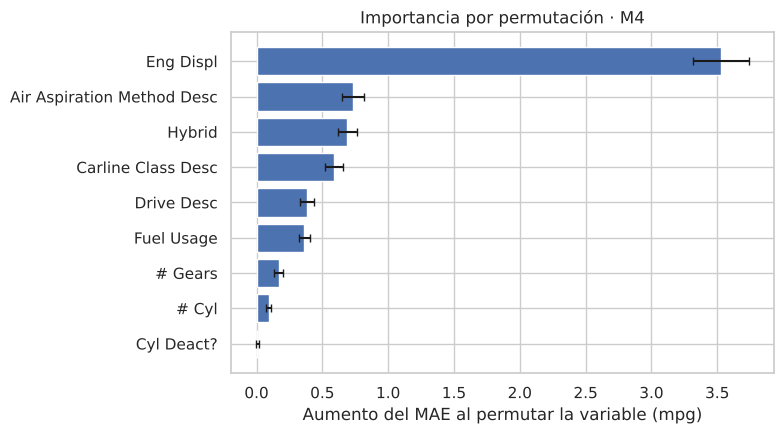

,Aumento del MAE (mpg),± std
Eng Displ,3.528,0.216
Air Aspiration Method Desc,0.735,0.084
Hybrid,0.690,0.071
Carline Class Desc,0.585,0.069
Drive Desc,0.384,0.052
Fuel Usage,0.364,0.042
# Gears,0.167,0.032
# Cyl,0.091,0.018
Cyl Deact?,0.006,0.013


In [15]:
pi = permutation_importance(r4["_model"], r4["_X_test"], r4["_y_test"], n_repeats=20,
                            random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
imp = pd.DataFrame({"Aumento del MAE (mpg)": pi.importances_mean, "± std": pi.importances_std},
                   index=r4["_X_test"].columns).sort_values("Aumento del MAE (mpg)")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp.index, imp["Aumento del MAE (mpg)"], xerr=imp["± std"], color="#4C72B0", capsize=3)
ax.set(xlabel="Aumento del MAE al permutar la variable (mpg)", title="Importancia por permutación · M4")
fig.tight_layout(); fig.savefig("../reports/figures/02_M4_importancia_permutacion.png", dpi=150, bbox_inches="tight")
plt.show()
imp.sort_values("Aumento del MAE (mpg)", ascending=False).round(3)

## 9. Conclusiones

* **Modelo seleccionado: Gradient Boosting con one-hot (M4).** Sobre familias de modelo no vistas alcanza
  **R² ≈ 0,91 y MAE ≈ 1,4 mpg**, frente a 4,9 mpg de la referencia y 2,0 mpg del mejor modelo lineal.
* **La codificación importa más que el algoritmo lineal:** pasar de indicadores binarios (M1) a one-hot (M3) reduce el
  MAE agrupado de 2,6 a 2,0 mpg. El término polinómico (M2) recupera parte de la no linealidad, pero el Gradient
  Boosting la captura mejor.
* **La validación es honesta:** la diferencia entre CV aleatoria y CV agrupada por familia es pequeña (≈ 0,01-0,02 de R²),
  por lo que las variantes de un mismo modelo no estaban inflando los resultados en este dataset.
* **Qué mueve el consumo:** la cilindrada domina con diferencia (permutarla multiplica el error); después sobrealimentación,
  hibridación y clase de vehículo. Retirar `Hybrid` hunde el R² de 0,91 a 0,77, y la cilindrada sola explica ≈ 0,61.
* **Recortar extremos no es una mejora:** reduce el MAE sólo porque elimina 23 híbridos, los casos más difíciles. Se mantienen.
* **Para CO₂ el modelo lineal funciona mejor que para mpg** (R² 0,85 frente a 0,84), coherente con que el CO₂ es
  proporcional al combustible por distancia.
* **Limitación principal:** el error en híbridos (MAE ≈ 4,9 mpg) es casi cuatro veces el de los convencionales
  (≈ 1,3 mpg). La guía no informa de capacidad de batería ni potencia eléctrica; añadirlas es la mejora con mayor retorno.